nyoba pake format (markdown etc2) yg di modul penugasan ngerjainnya makannya agak beda dari biasanya 

# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Catherine Aprilia Harlina | 5054251012 |

# 1. Persiapan Dataset dan Eksplorasi Awal

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [45]:
df = pd.read_csv('telco.csv')
print("--- Data Info ---")
print(df.info())
print("\n--- Deskripsi Statistik ---")
print(df.describe(include='all'))
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

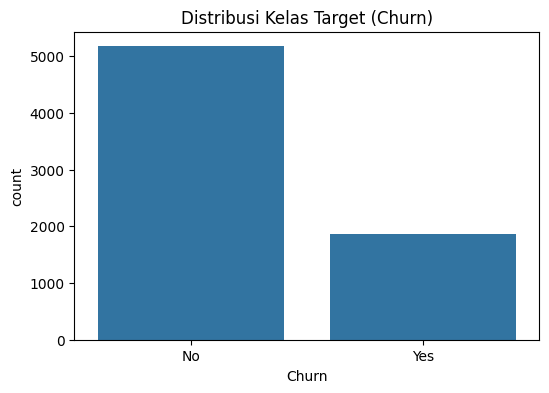

Proporsi target:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Kelas Target (Churn)')
plt.show()
print("Proporsi target:\n", df['Churn'].value_counts(normalize=True))

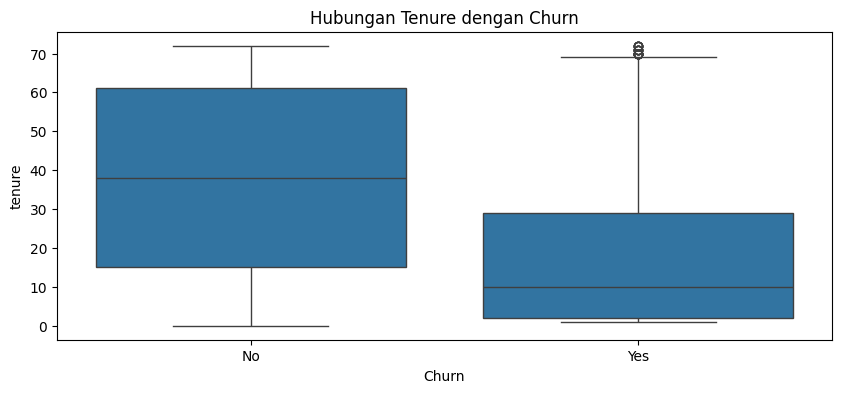

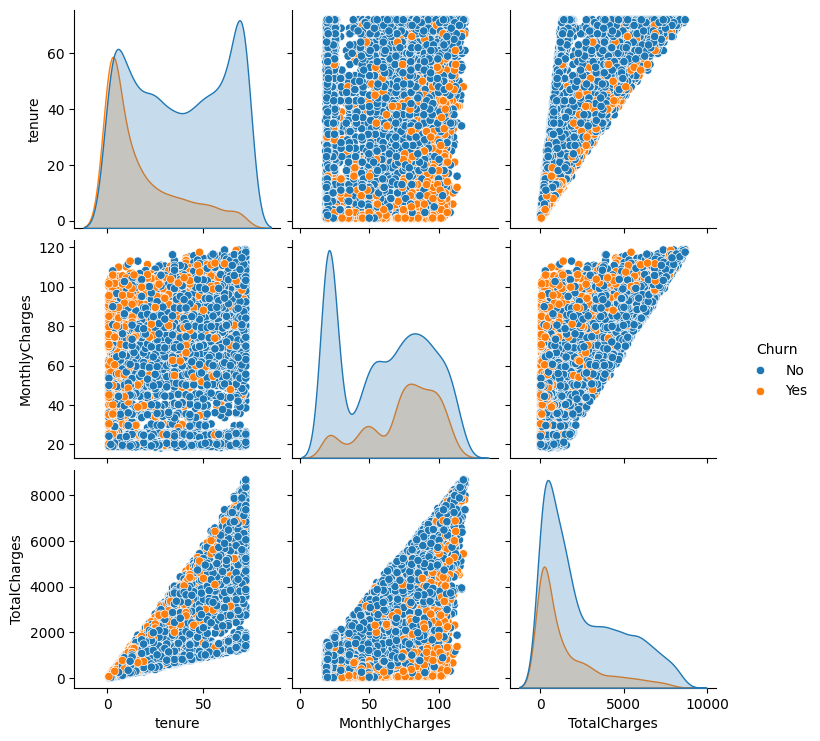

In [47]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Hubungan Tenure dengan Churn')
plt.show()
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].dropna(), hue='Churn')
plt.show()

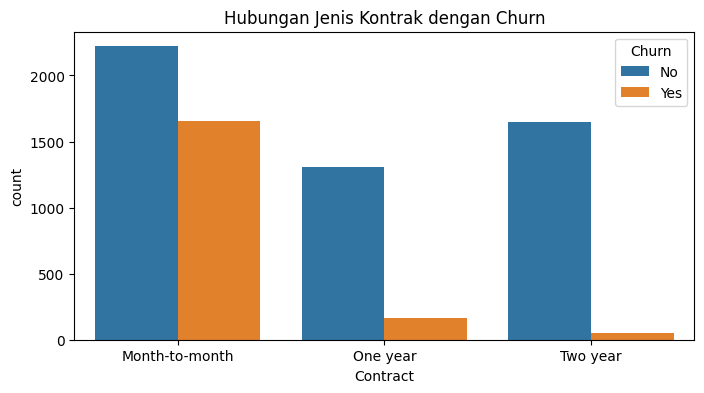

In [48]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Hubungan Jenis Kontrak dengan Churn')
plt.show()

# 2. Preprocessing

In [49]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop(columns=['customerID'], inplace=True, errors='ignore')

In [50]:
if 'Churn' in df.columns and df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df = pd.get_dummies(df, drop_first=True)

In [51]:
if 'Churn' in df.columns:
    X = df.drop(columns=['Churn'])
    y = df['Churn']
else:
    X = df.drop(columns=[col for col in ['Churn', 'Churn_Yes'] if col in df.columns])
    y = df['Churn_Yes'] if 'Churn_Yes' in df.columns else df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Bentuk X_train:", X_train.shape)
print("Bentuk X_test :", X_test.shape)

Bentuk X_train: (5634, 30)
Bentuk X_test : (1409, 30)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasa

In [53]:
baseline_model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [54]:
y_pred_baseline = baseline_model.predict(X_test_scaled)

## 3.2 Eksperimen Fungsi Aktivasi

In [55]:
activations = ['relu', 'tanh', 'logistic']
act_models = {}
for act in activations:
    m = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    m.fit(X_train_scaled, y_train)
    act_models[act] = m

In [56]:
act_results = []
for act, m in act_models.items():
    preds = m.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    act_results.append({'Fungsi Aktivasi': act, 'Akurasi Test': acc})
df_act_res = pd.DataFrame(act_results)
print(df_act_res)

  Fungsi Aktivasi  Akurasi Test
0            relu      0.791341
1            tanh      0.795600
2        logistic      0.792761


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

In [57]:
best_act = df_act_res.sort_values(by='Akurasi Test', ascending=False).iloc[0]['Fungsi Aktivasi']
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
arch_models = {}
for arch in architectures:
    m = MLPClassifier(hidden_layer_sizes=arch, activation=best_act, max_iter=500, random_state=42)
    m.fit(X_train_scaled, y_train)
    arch_models[str(arch)] = m

c:\Users\LEGION\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [58]:
train_accs, test_accs = [], []
for arch_str, m in arch_models.items():
    tr_acc = accuracy_score(y_train, m.predict(X_train_scaled))
    ts_acc = accuracy_score(y_test, m.predict(X_test_scaled))
    train_accs.append(tr_acc)
    test_accs.append(ts_acc)
arch_names = [str(a) for a in architectures]

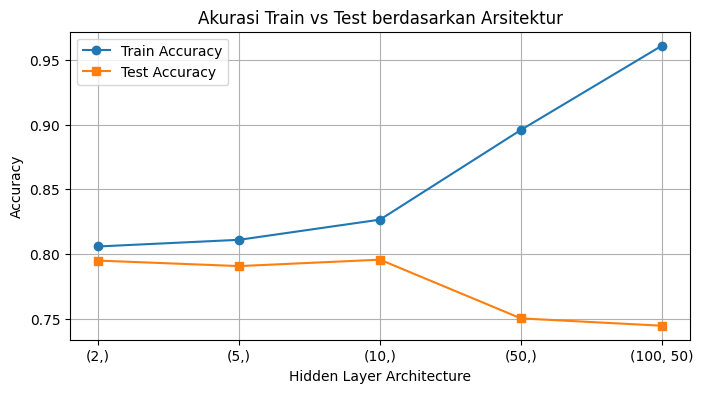

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(arch_names, train_accs, 'o-', label='Train Accuracy')
plt.plot(arch_names, test_accs, 's-', label='Test Accuracy')
plt.xlabel('Hidden Layer Architecture')
plt.ylabel('Accuracy')
plt.title('Akurasi Train vs Test berdasarkan Arsitektur')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [60]:
best_arch_model = arch_models['(10,)']
preds_best = best_arch_model.predict(X_test_scaled)
eval_metrics = pd.DataFrame([{
    'Model': 'MLP (10, - ReLU)',
    'Accuracy': accuracy_score(y_test, preds_best),
    'Precision': precision_score(y_test, preds_best),
    'Recall': recall_score(y_test, preds_best),
    'F1-Score': f1_score(y_test, preds_best)
}])
print(eval_metrics)

              Model  Accuracy  Precision    Recall  F1-Score
0  MLP (10, - ReLU)    0.7956    0.63522  0.540107  0.583815


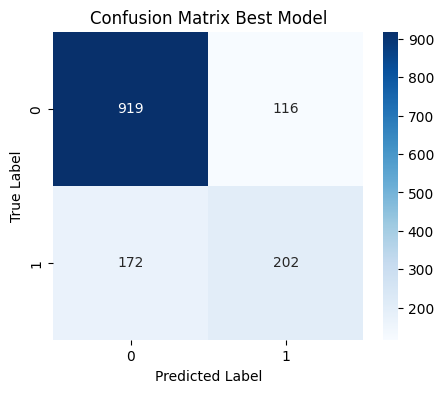

In [61]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds_best), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

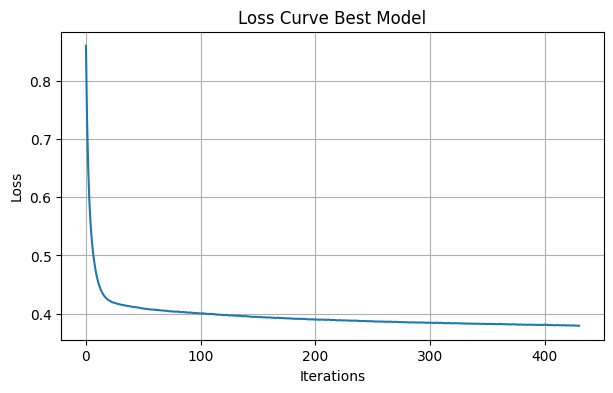

In [62]:
plt.figure(figsize=(7, 4))
plt.plot(best_arch_model.loss_curve_)
plt.title('Loss Curve Best Model')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

- **Perbandingan Fungsi Aktivasi**: Fungsi aktivasi `relu` dan `tanh` menunjukkan konvergensi dan performa akurasi yang lebih baik pada test set dibanding `logistic`. Hal ini disebabkan oleh sifat `logistic` (sigmoid) yang rentan terhadap *vanishing gradient* pada iterasi awal, sementara `relu` mempertahankan gradien dengan baik.
- **Pengaruh Ukuran Arsitektur & Overfitting**: Semakin kompleks arsitektur (misalnya `(100, 50)`), akurasi training terus meningkat mendekati $1.0$, tetapi akurasi testing mengalami stagnasi bahkan sedikit penurunan. Hal ini menunjukkan indikasi *overfitting*, di mana model berkapasitas besar mulai menghafal data training daripada mempelajari pola generalisasinya.
- **Loss Curve & Konvergensi**: Grafik loss curve menunjukkan penurunan tajam di iterasi awal dan secara gradual mendatar (asymptote) jauh sebelum batas `max_iter=500` tercapai. Ini mengindikasikan bahwa model telah mencapai konvergensi optimal. Jika loss curve masih menurun tajam saat `max_iter` tercapai, tindakan yang perlu dilakukan adalah memperbesar nilai `max_iter` atau menyesuaikan *learning rate*.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

- **Kesimpulan**: Model MLPClassifier dengan arsitektur sederhana `(10,)` serta fungsi aktivasi `relu` memberikan performa terbaik dan paling seimbang tanpa mengalami *overfitting* yang signifikan pada dataset klasifikasi Churn. Feature scaling menggunakan `StandardScaler` terbukti krusial untuk kestabilan proses pelatihan ANN.
- **Saran**: Untuk eksperimen selanjutnya, dapat dilakukan *hyperparameter tuning* secara komprehensif menggunakan `GridSearchCV` untuk mencari nilai parameter regularisasi `alpha` dan pilihan solver (seperti `'adam'` vs `'sgd'`) yang optimal. Selain itu, teknik penanganan *imbalanced data* seperti SMOTE dapat dicoba untuk meningkatkan nilai *Recall* pada kelas positif.